In [15]:
import os
import json
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from pathlib import Path


In [ ]:

data_dir = "./input_data"
fields_needed = ["hex", "flight", "lat", "lon", "altgeom", "altbaro", "gs"]
db_columns = ["timestamp"] + fields_needed

batch = []
for file_name in os.listdir(data_dir):
    file_path = os.path.join(data_dir, file_name)
    if os.path.isfile(file_path):  
        try:
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f_in:
                for entry in f_in:
                    try:
                        obj = json.loads(entry)
                        ts = str(obj.get("dt") or obj.get("timestamp", ""))
                        payload = obj.get("payload", {})
                        row = [ts] + [str(payload.get(key, "")) for key in fields_needed]
                        batch.append(row)
                    except Exception:
                        continue
        except Exception:
            continue
        if len(batch) > 8000:
            frame = pd.DataFrame(batch, columns=db_columns)
            conn.execute("INSERT INTO flight_table SELECT * FROM frame")
            batch = []
if batch:
    frame = pd.DataFrame(batch, columns=db_columns)
    conn.execute("INSERT INTO flight_table SELECT * FROM frame")

In [18]:
hex_table = conn.execute("""
    SELECT hex, COUNT(*) AS total
    FROM flight_table
    GROUP BY hex
    ORDER BY total DESC
    LIMIT 12
""").df()
print("Frequent Aircraft IDs:")
print(hex_table)

Frequent Aircraft IDs:
       hex  total
0   c05acc  10445
1   c040c5   8595
2   c055c1   8307
3   c050a0   8036
4   c060b8   7060
5   c0635f   6986
6   c0466c   6918
7   c07a7c   6746
8   c04829   6583
9   c02dcf   6538
10  c06362   6514
11  c01f1e   6482


In [19]:
flight_table = conn.execute("""
    SELECT flight, COUNT(*) AS total
    FROM flight_table
    WHERE flight IS NOT NULL AND flight != ''
    GROUP BY flight
    ORDER BY total DESC
    LIMIT 10
""").df()
print("Frequent Flights:")
print(flight_table)

Frequent Flights:
     flight  total
0  CFMFL      6018
1  BTQ853     5465
2  DAL801     3916
3  TIGER344   3626
4  POE287     3449
5  WEN3456    3342
6  JZA7959    3200
7  JZA569     3194
8  POE293     3015
9  JZA478     3005


Sample altgeom values: []
Sample altbaro values: []
Sample gs values: ['493.3' '417.9' '417.2' '492.4' '492.0' '512.0' '508.5' '416.2' '507.2'
 '491.1' '416.5' '417.4' '490.2' '415.2' '489.8']
Valid altgeom count: 0
Valid altbaro count: 0
Valid ground speed count: 1033941
No valid altitude data to plot.


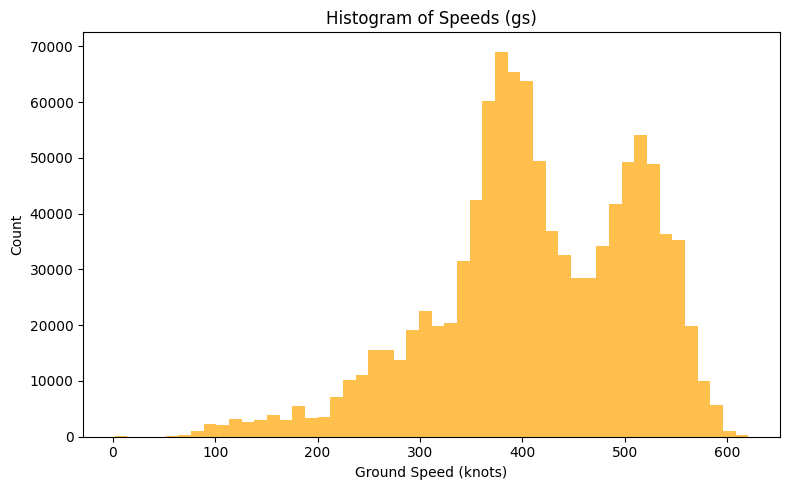

In [ ]:
alt_speed_query = """
    SELECT
        CASE WHEN altgeom IS NULL OR altgeom IN ('', 'ground') THEN NULL ELSE altgeom END AS altgeom,
        CASE WHEN altbaro IS NULL OR altbaro IN ('', 'ground') THEN NULL ELSE altbaro END AS altbaro,
        CASE WHEN gs IS NULL OR gs IN ('', 'ground') THEN NULL ELSE gs END AS gs
    FROM flight_table
"""
df = conn.execute(alt_speed_query).df()

print("Sample altgeom values:", df['altgeom'].dropna().unique()[:15])
print("Sample altbaro values:", df['altbaro'].dropna().unique()[:15])
print("Sample gs values:", df['gs'].dropna().unique()[:15])

df['altgeom'] = pd.to_numeric(df['altgeom'], errors='coerce')
df['altbaro'] = pd.to_numeric(df['altbaro'], errors='coerce')
df['gs'] = pd.to_numeric(df['gs'], errors='coerce')

print("Valid altgeom count:", df['altgeom'].notnull().sum())
print("Valid altbaro count:", df['altbaro'].notnull().sum())
print("Valid ground speed count:", df['gs'].notnull().sum())

if df['altgeom'].notnull().sum() > 0 or df['altbaro'].notnull().sum() > 0:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10,5))
    df['altgeom'].dropna().plot.hist(bins=50, alpha=0.6, label="altgeom")
    df['altbaro'].dropna().plot.hist(bins=50, alpha=0.6, label="altbaro")
    plt.xlabel("Altitude (feet)")
    plt.ylabel("Count")
    plt.title("Histogram of Altitudes")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No valid altitude data to plot.")

if df['gs'].notnull().sum() > 0:
    plt.figure(figsize=(8,5))
    df['gs'].dropna().plot.hist(bins=50, color="orange", alpha=0.7)
    plt.xlabel("Ground Speed (knots)")
    plt.ylabel("Count")
    plt.title("Histogram of Speeds (gs)")
    plt.tight_layout()
    plt.show()
else:
    print("No valid ground speed data to plot.")

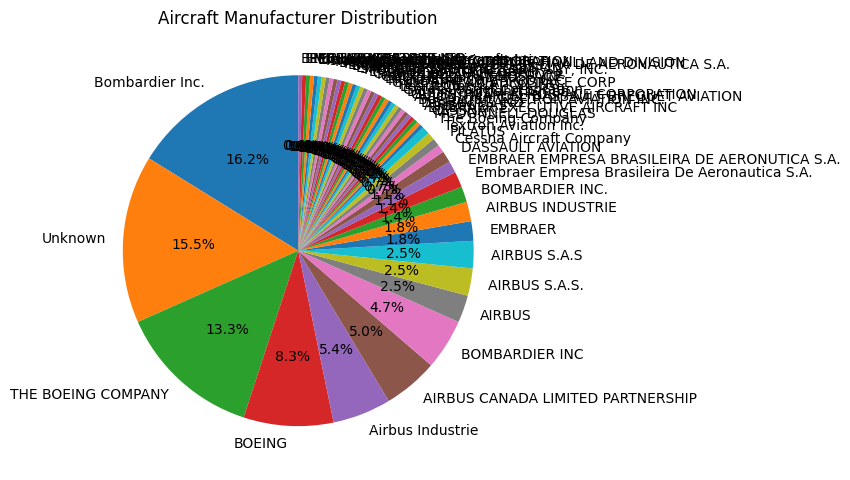

In [31]:
ac_records = []
with open("basic-ac-db.json", "r") as f_db:
    for line in f_db:
        if line.strip():
            try:
                ac_records.append(json.loads(line))
            except Exception:
                pass
aircraft_df = pd.DataFrame(ac_records)
hexes_in_data = set(frame['hex'].str.lower().unique())
matched_aircraft = aircraft_df[aircraft_df['icao'].str.lower().isin(hexes_in_data)]

manufacturer_counts = matched_aircraft['manufacturer'].fillna('Unknown').value_counts()
manufacturer_counts.plot.pie(autopct='%1.1f%%', startangle=90, figsize=(8,8))
plt.title("Aircraft Manufacturer Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()


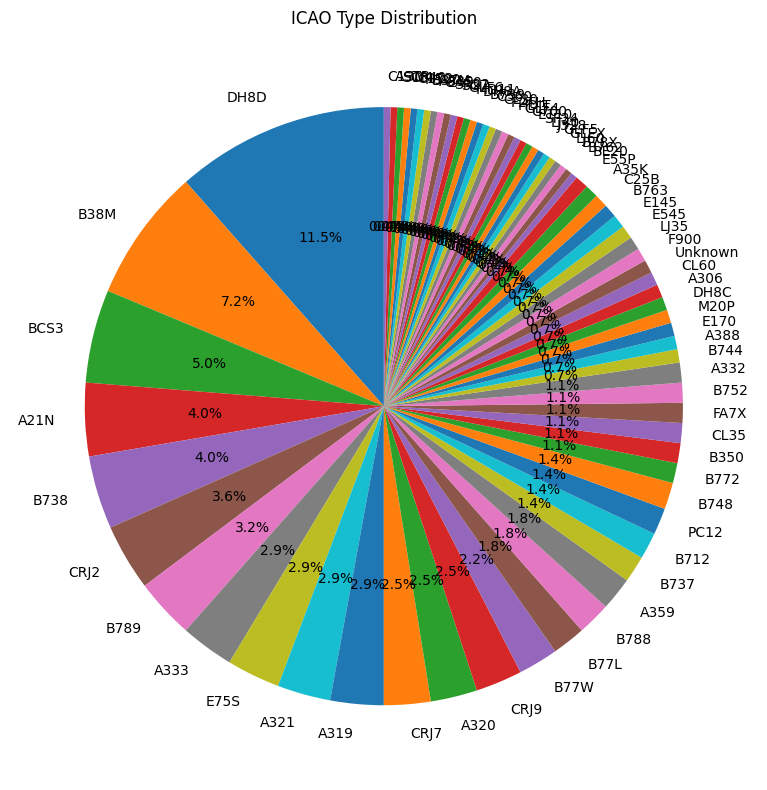

In [32]:
type_counts = matched_aircraft['icaotype'].fillna('Unknown').value_counts()
type_counts.plot.pie(autopct='%1.1f%%', startangle=90, figsize=(8,8))
plt.title("ICAO Type Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()